# HypeGuard — EDA & Feature Engineering Demo
### Show this notebook tomorrow. It IS your presentation.
Run cells top to bottom. Each cell = one talking point.

In [6]:
%pip install feedparser yfinance bs4

  Using cached bs4-0.0.2-py2.py3-none-any.whl (1.2 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# ── SETUP ─────────────────────────────────────────────────────────────
import sys
import os

# Insert backend/src AT THE VERY START of sys.path so it overrides site-packages
src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'backend', 'src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scraper import collect_all
from features import (
    compute_volume_features, compute_price_features,
    compute_news_features, compute_cross_features, build_feature_vector
)

# Styling
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a1a',
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.edgecolor': '#444',
    'grid.color': '#333',
    'figure.figsize': (14, 5),
    'font.family': 'monospace',
})

HYPE_COLOR    = '#ef4444'   # red
ORGANIC_COLOR = '#22c55e'   # green
NEUTRAL_COLOR = '#6b7280'   # gray
ACCENT_COLOR  = '#f59e0b'   # amber

print('✓ Setup complete')

✓ Setup complete


---
## Step 1: Data Collection
**Talking point:** *We pull 60 days of OHLCV data + 30 recent news headlines per ticker, with zero API keys for the core pipeline.*

In [2]:
# Fetch data for 3 contrasting tickers
DEMO_TICKERS = ['GME', 'NVDA', 'AAPL']

raw_data = {}
for ticker in DEMO_TICKERS:
    raw_data[ticker] = collect_all(ticker, days=60)
    dq = raw_data[ticker]['data_quality']
    print(f"\n{ticker}")
    print(f"  Price rows      : {dq['price_rows']}")
    print(f"  News articles   : {dq['news_count']}")
    print(f"  Earnings dates  : {raw_data[ticker]['earnings_dates']}")
    if raw_data[ticker]['news']:
        print(f"  Top headline    : {raw_data[ticker]['news'][0]['title'][:70]}")

INFO | ==================================================
INFO |   HypeGuard Data Collection: GME
INFO | ==================================================
INFO | Fetching price data for GME (60 days)...
INFO |   ✓ 43 trading days fetched for GME
INFO | Fetching news for GME from Google News RSS...
INFO |   ✓ 30 news articles fetched for GME
WARNING | Could not fetch earnings dates for GME: 'dict' object has no attribute 'empty'
INFO | 
Data Quality Report for GME:
INFO |   has_price_data: True
INFO |   has_news: True
INFO |   has_earnings: False
INFO |   price_rows: 43
INFO |   news_count: 30
INFO | ==================================================
INFO |   HypeGuard Data Collection: NVDA
INFO | ==================================================
INFO | Fetching price data for NVDA (60 days)...
INFO |   ✓ 43 trading days fetched for NVDA



GME
  Price rows      : 43
  News articles   : 30
  Earnings dates  : []
  Top headline    : What Options Data Says Could Come Next for GME Stock After GameStop Re


INFO | Fetching news for NVDA from Google News RSS...
INFO |   ✓ 30 news articles fetched for NVDA
WARNING | Could not fetch earnings dates for NVDA: 'dict' object has no attribute 'empty'
INFO | 
Data Quality Report for NVDA:
INFO |   has_price_data: True
INFO |   has_news: True
INFO |   has_earnings: False
INFO |   price_rows: 43
INFO |   news_count: 30
INFO | ==================================================
INFO |   HypeGuard Data Collection: AAPL
INFO | ==================================================
INFO | Fetching price data for AAPL (60 days)...



NVDA
  Price rows      : 43
  News articles   : 30
  Earnings dates  : []
  Top headline    : Here's What Could Send Nvidia Stock to New All-Time Highs - The Motley


INFO |   ✓ 43 trading days fetched for AAPL
INFO | Fetching news for AAPL from Google News RSS...
INFO |   ✓ 30 news articles fetched for AAPL
WARNING | Could not fetch earnings dates for AAPL: 'dict' object has no attribute 'empty'
INFO | 
Data Quality Report for AAPL:
INFO |   has_price_data: True
INFO |   has_news: True
INFO |   has_earnings: False
INFO |   price_rows: 43
INFO |   news_count: 30



AAPL
  Price rows      : 43
  News articles   : 30
  Earnings dates  : []
  Top headline    : Apple Stock Is Doing Something It Hasn't Done Since 2022. Should You B


---
## Step 2: Feature Engineering — Volume Features
**Talking point:** *RVOL (Relative Volume) is the core pump indicator. A 3x spike on GME with no earnings = red flag. The same spike on NVDA after an earnings beat = organic.*

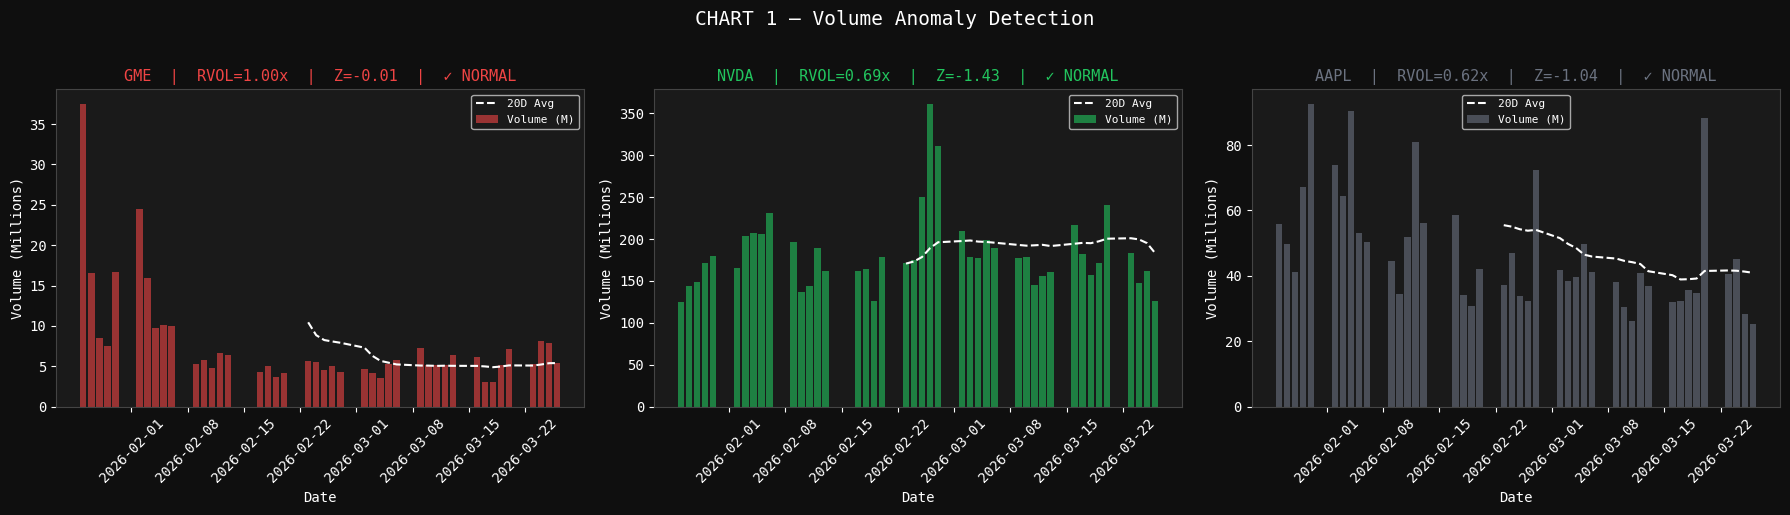

✓ Saved: chart1_volume_anomaly.png


In [3]:
# ── CHART 1: Volume Timeline + RVOL for all 3 tickers ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CHART 1 — Volume Anomaly Detection', color='white', fontsize=14, y=1.02)

ticker_colors = {'GME': HYPE_COLOR, 'NVDA': ORGANIC_COLOR, 'AAPL': NEUTRAL_COLOR}

for ax, ticker in zip(axes, DEMO_TICKERS):
    df = raw_data[ticker]['price_df']
    if df.empty:
        ax.text(0.5, 0.5, f'No data\nfor {ticker}', ha='center', va='center', color='white')
        continue

    avg_vol = df['volume'].rolling(20).mean()
    rvol    = df['volume'] / avg_vol
    color   = ticker_colors[ticker]

    ax.bar(df.index, df['volume'] / 1e6, color=color, alpha=0.6, width=0.8, label='Volume (M)')
    ax.plot(df.index, avg_vol / 1e6, color='white', linewidth=1.5, linestyle='--', label='20D Avg')

    # Highlight spikes (RVOL > 2.5)
    spike_mask = rvol > 2.5
    if spike_mask.any():
        ax.bar(df.index[spike_mask], df['volume'][spike_mask] / 1e6,
               color=ACCENT_COLOR, alpha=1.0, width=0.8, label='⚠ Spike (RVOL>2.5x)')

    vol_feats = compute_volume_features(df)
    ax.set_title(f'{ticker}  |  RVOL={vol_feats["rvol"]:.2f}x  |  '
                 f'Z={vol_feats["volume_zscore"]:.2f}  |  '
                 f'{"🚨 ANOMALY" if vol_feats["is_volume_anomaly"] else "✓ NORMAL"}',
                 color=color, fontsize=11)
    ax.set_xlabel('Date')
    ax.set_ylabel('Volume (Millions)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/chart1_volume_anomaly.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('✓ Saved: chart1_volume_anomaly.png')

---
## Step 3: Feature Engineering — Price Features (RSI + Bollinger)
**Talking point:** *RSI > 75 + wide Bollinger Bands = overbought AND volatile. Alone, not enough to flag a pump. Combined with volume and news, it's part of the case.*

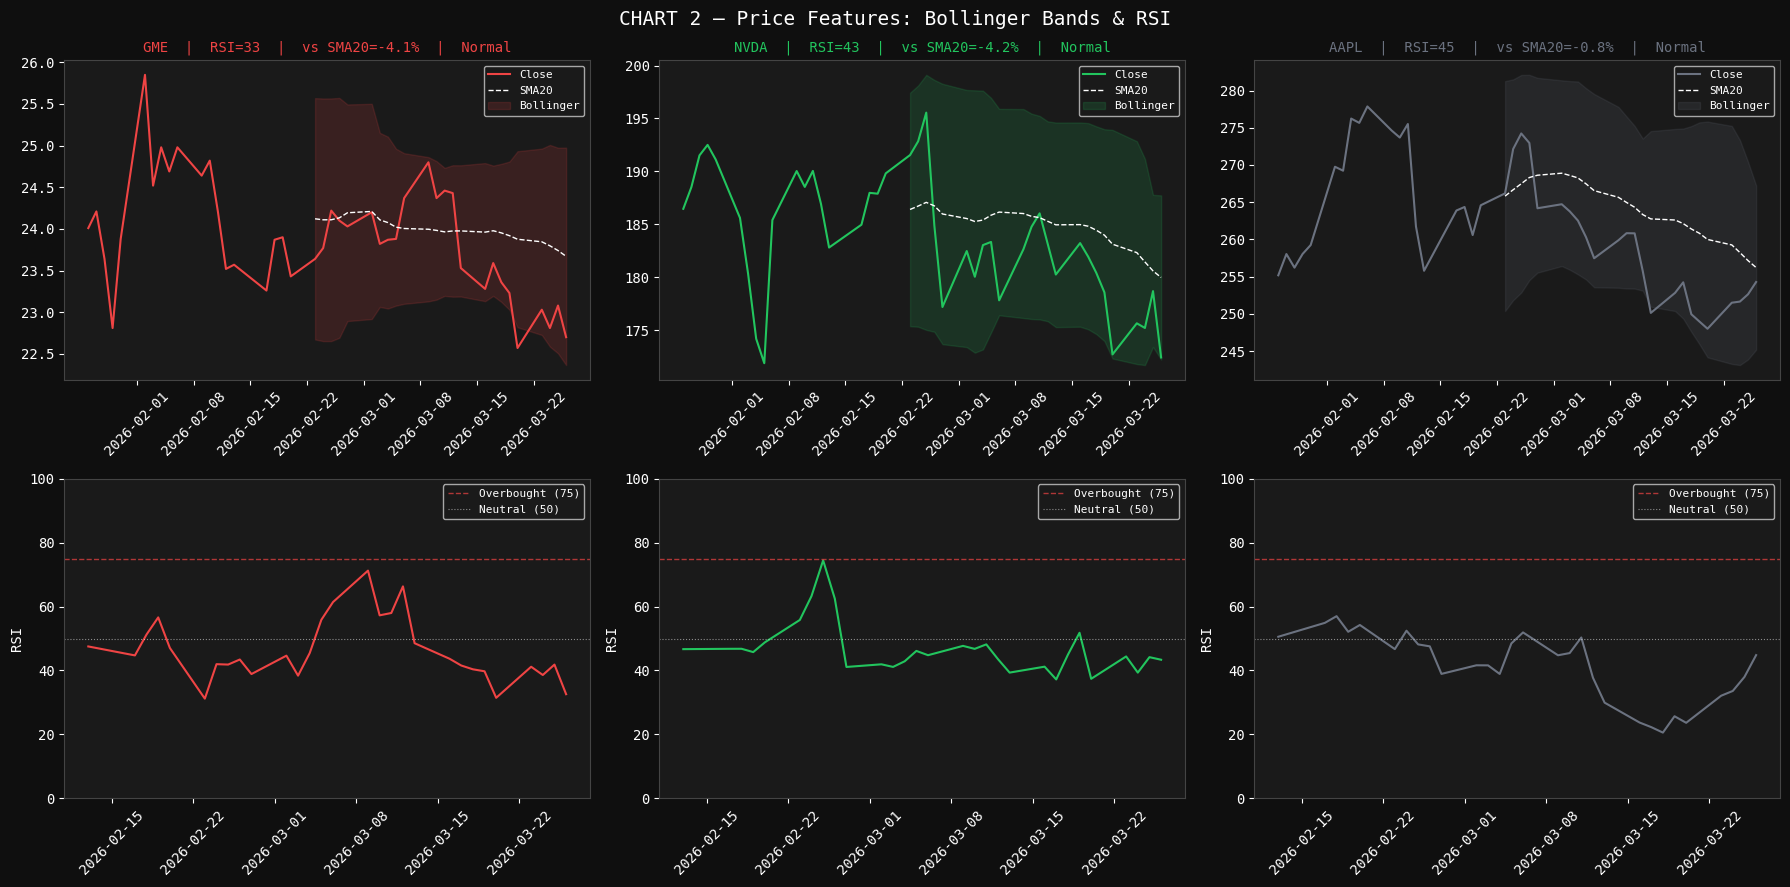

✓ Saved: chart2_price_rsi.png


In [4]:
# ── CHART 2: Price + Bollinger Bands + RSI ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('CHART 2 — Price Features: Bollinger Bands & RSI', color='white', fontsize=14)

for col, ticker in enumerate(DEMO_TICKERS):
    df = raw_data[ticker]['price_df']
    if df.empty:
        continue
    color = ticker_colors[ticker]

    sma20   = df['close'].rolling(20).mean()
    std20   = df['close'].rolling(20).std()
    bb_up   = sma20 + 2 * std20
    bb_low  = sma20 - 2 * std20

    # Price + Bollinger
    ax1 = axes[0][col]
    ax1.plot(df.index, df['close'], color=color, linewidth=1.5, label='Close')
    ax1.plot(df.index, sma20, color='white', linewidth=1, linestyle='--', label='SMA20')
    ax1.fill_between(df.index, bb_up, bb_low, alpha=0.15, color=color, label='Bollinger')
    pf = compute_price_features(df)
    ax1.set_title(f'{ticker}  |  RSI={pf["rsi_14"]:.0f}  |  '
                  f'vs SMA20={pf["price_vs_sma20"]:+.1f}%  |  '
                  f'{"🔥 OVERBOUGHT" if pf["is_overbought"] else "Normal"}',
                  color=color, fontsize=10)
    ax1.legend(fontsize=8)
    ax1.tick_params(axis='x', rotation=45)

    # RSI panel
    ax2 = axes[1][col]
    delta = df['close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rsi   = 100 - (100 / (1 + gain/loss.replace(0, np.nan)))

    ax2.plot(df.index, rsi, color=color, linewidth=1.5)
    ax2.axhline(75, color=HYPE_COLOR, linestyle='--', linewidth=1, alpha=0.7, label='Overbought (75)')
    ax2.axhline(50, color='white', linestyle=':', linewidth=0.8, alpha=0.5, label='Neutral (50)')
    ax2.fill_between(df.index, rsi, 75, where=(rsi > 75), color=HYPE_COLOR, alpha=0.3)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('RSI')
    ax2.legend(fontsize=8)
    ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/chart2_price_rsi.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('✓ Saved: chart2_price_rsi.png')

---
## Step 4: News Feature Engineering
**Talking point:** *We don't just ask 'is this positive news?' We ask: How many articles appeared in 6 hours? Are they all saying the same thing? Is the language extreme? These patterns are statistically different between organic moves and pumps.*


GME News Features:
  Total Headlines        : 30
  Extreme Language Ratio : 0.0%
  Source Diversity       : 60.0%
  Headline Similarity    : 10.3%
  Buzz Density           : 3.75 articles/window
  Spam Pattern Detected  : False

NVDA News Features:
  Total Headlines        : 30
  Extreme Language Ratio : 0.0%
  Source Diversity       : 43.3%
  Headline Similarity    : 11.3%
  Buzz Density           : 3.75 articles/window
  Spam Pattern Detected  : False

AAPL News Features:
  Total Headlines        : 30
  Extreme Language Ratio : 0.0%
  Source Diversity       : 70.0%
  Headline Similarity    : 9.9%
  Buzz Density           : 3.75 articles/window
  Spam Pattern Detected  : False


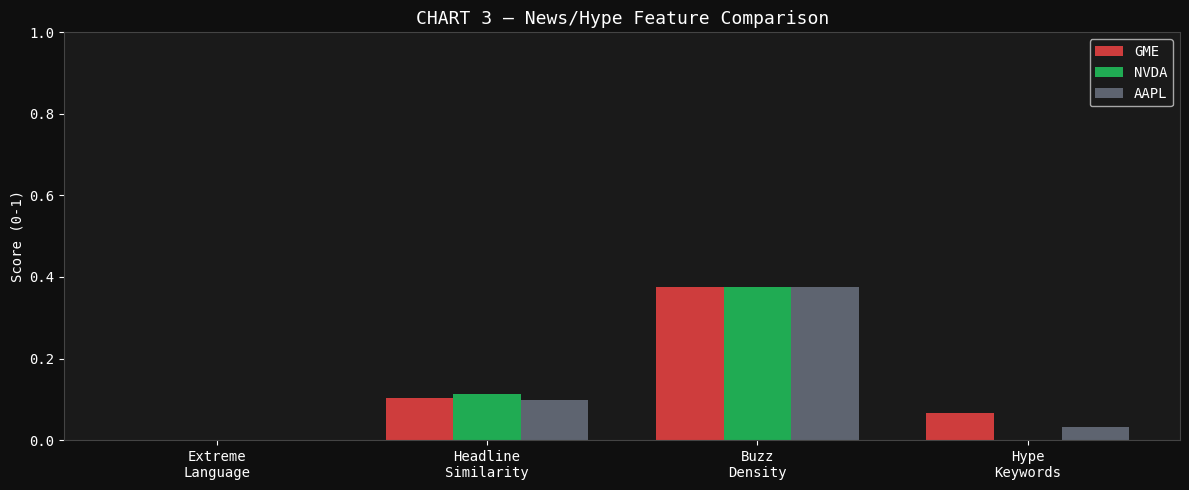

✓ Saved: chart3_news_features.png


In [5]:
# ── CHART 3: News Feature Comparison Across Tickers ───────────────────
news_summary = {}
for ticker in DEMO_TICKERS:
    nf = compute_news_features(raw_data[ticker]['news'])
    news_summary[ticker] = nf
    print(f"\n{ticker} News Features:")
    print(f"  Total Headlines        : {nf['total_headlines']}")
    print(f"  Extreme Language Ratio : {nf['extreme_language_ratio']:.1%}")
    print(f"  Source Diversity       : {nf['source_diversity']:.1%}")
    print(f"  Headline Similarity    : {nf['headline_similarity']:.1%}")
    print(f"  Buzz Density           : {nf['buzz_density']:.2f} articles/window")
    print(f"  Spam Pattern Detected  : {nf['is_spam_pattern']}")

# Radar / bar comparison
metrics = ['extreme_language_ratio', 'headline_similarity',
           'buzz_density', 'moderate_hype_ratio']
metric_labels = ['Extreme\nLanguage', 'Headline\nSimilarity', 'Buzz\nDensity', 'Hype\nKeywords']

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f0f0f')

x = np.arange(len(metrics))
width = 0.25

for i, (ticker, color) in enumerate(ticker_colors.items()):
    nf = news_summary[ticker]
    vals = []
    for m in metrics:
        v = nf.get(m, 0)
        # normalize buzz_density to 0-1 for display
        if m == 'buzz_density': v = min(v / 10, 1.0)
        vals.append(v)
    bars = ax.bar(x + i*width, vals, width, label=ticker, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.set_ylabel('Score (0-1)')
ax.set_title('CHART 3 — News/Hype Feature Comparison', color='white', fontsize=13)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../data/chart3_news_features.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('✓ Saved: chart3_news_features.png')

---
## Step 5: Complete Feature Vector
**Talking point:** *Every raw data point goes through our pipeline and becomes a 21-dimensional feature vector. This is what the ML model will see — not raw prices, but engineered signals.*

In [6]:
# ── Build full feature vectors for all tickers ────────────────────────
feature_vectors = {}
for ticker in DEMO_TICKERS:
    fv = build_feature_vector(raw_data[ticker])
    feature_vectors[ticker] = fv

# Display as a comparison table
rows = []
feature_names = feature_vectors[DEMO_TICKERS[0]]['feature_names']

for fname in feature_names:
    row = {'Feature': fname}
    for ticker in DEMO_TICKERS:
        row[ticker] = feature_vectors[ticker]['flat_features'].get(fname, 0)
    rows.append(row)

comparison_df = pd.DataFrame(rows).set_index('Feature')

print('\n──── FEATURE VECTOR COMPARISON ────')
print(comparison_df.to_string(float_format=lambda x: f'{x:.4f}'))

print('\n──── PSEUDO LABELS (Ground Truth for Training) ────')
for ticker in DEMO_TICKERS:
    cf = feature_vectors[ticker]['cross_features']
    print(f'  {ticker:6s}  →  Hype Score: {cf["hype_score_raw"]:.1%}  |  Label: {cf["pseudo_label"]}')

INFO | Building feature vector for GME...
INFO |   ✓ Feature vector built: 21 features, label=NEUTRAL
INFO | Building feature vector for NVDA...
INFO |   ✓ Feature vector built: 21 features, label=NEUTRAL
INFO | Building feature vector for AAPL...
INFO |   ✓ Feature vector built: 21 features, label=NEUTRAL



──── FEATURE VECTOR COMPARISON ────
                           GME    NVDA    AAPL
Feature                                       
rvol                    0.9980  0.6870  0.6160
volume_zscore          -0.0070 -1.4330 -1.0450
vol_price_divergence   -0.6480 -2.8200 -0.0370
vol_spike_days          0.0000  0.0000  0.0000
vol_trend_slope_norm   -0.0150 -0.1369 -0.3379
log_return_1d          -0.0166 -0.0357  0.0065
price_vs_sma20         -4.1000 -4.1990 -0.7590
rsi_14                 32.5700 43.3600 44.8100
bb_width               11.0280  8.6220  8.6160
gap_open               -0.7370 -1.4050 -0.2470
range_expansion         1.0920  1.0460  1.3190
buzz_density            3.7500  3.7500  3.7500
extreme_language_ratio  0.0000  0.0000  0.0000
moderate_hype_ratio     0.0670  0.0000  0.0330
bearish_ratio           0.0330  0.1330  0.0000
source_diversity        0.6000  0.4330  0.7000
headline_similarity     0.1030  0.1130  0.0990
catalyst_flag           0.0000  0.0000  0.0000
hype_without_catalyst  

---
## Step 6: Feature Correlation Heatmap
**Talking point:** *Before training any model, we check which features are correlated. Correlated features add noise, not signal. This heatmap guides our feature selection.*

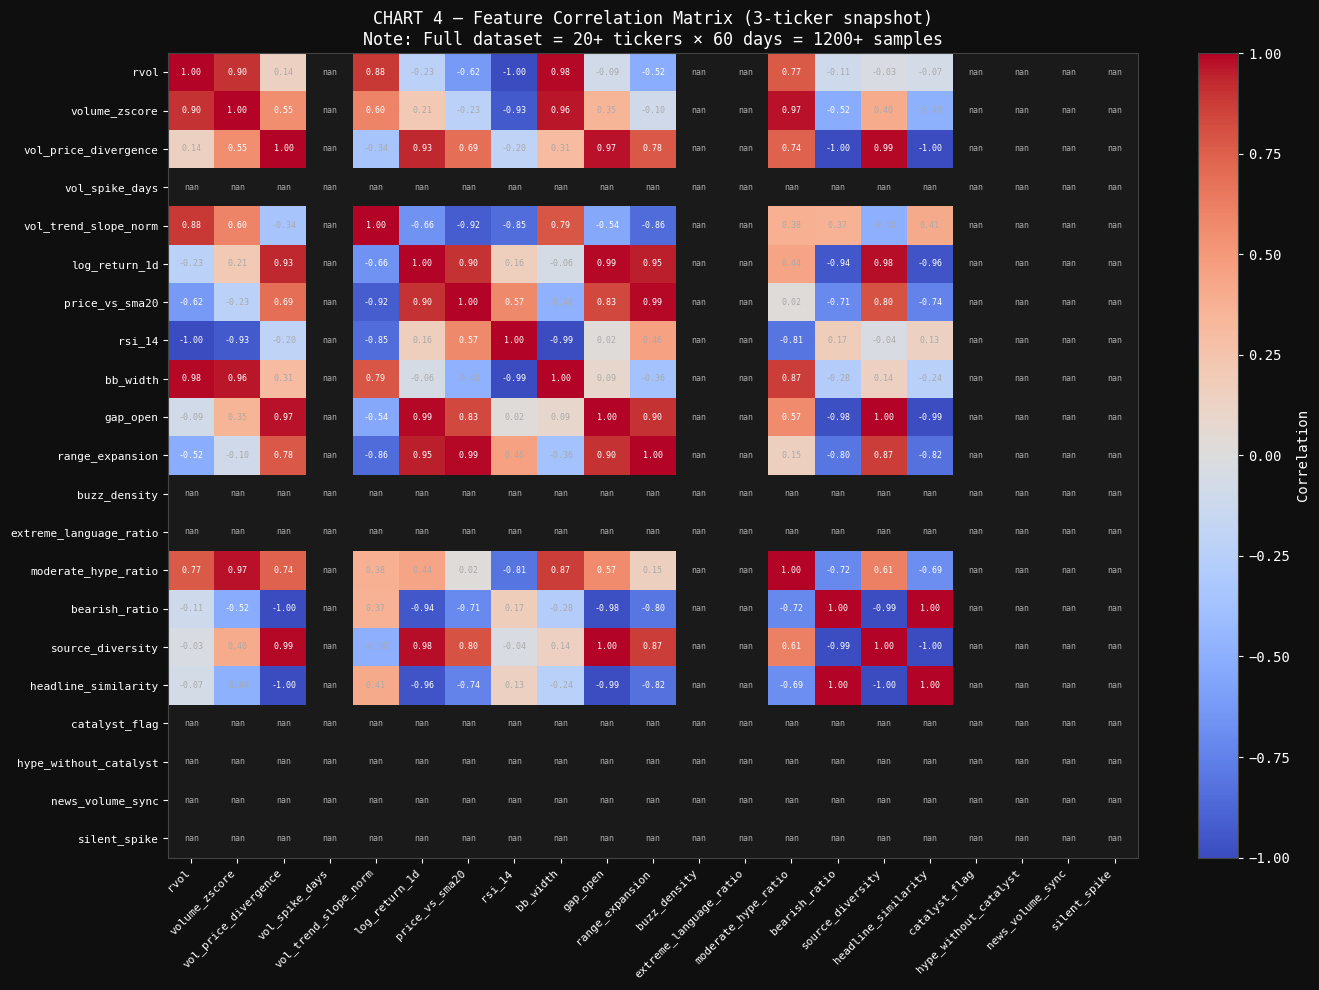

✓ Saved: chart4_correlation.png


In [7]:
# ── CHART 4: Feature Correlation Heatmap ─────────────────────────────
# Build a synthetic dataset from the 3 real tickers
# (In full project: expand to 20+ tickers across different time windows)

all_flat = []
for ticker in DEMO_TICKERS:
    flat = feature_vectors[ticker]['flat_features'].copy()
    flat['ticker'] = ticker
    all_flat.append(flat)

flat_df = pd.DataFrame(all_flat).drop(columns=['ticker'])

# If only 3 rows, note this is for demo — full project uses historical snapshots
corr = flat_df.T.corr() if len(flat_df) > 3 else flat_df.corr()

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#0f0f0f')

import matplotlib.colors as mcolors
cmap = plt.cm.RdYlGn

# Correlation across features
feature_corr = flat_df.corr()
im = ax.imshow(feature_corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Correlation')

ax.set_xticks(range(len(feature_corr.columns)))
ax.set_yticks(range(len(feature_corr.columns)))
ax.set_xticklabels(feature_corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(feature_corr.columns, fontsize=8)
ax.set_title('CHART 4 — Feature Correlation Matrix (3-ticker snapshot)\n'
             'Note: Full dataset = 20+ tickers × 60 days = 1200+ samples',
             color='white', fontsize=12)

# Annotate cells
for i in range(len(feature_corr)):
    for j in range(len(feature_corr)):
        val = feature_corr.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6, color='white' if abs(val) > 0.5 else '#aaa')

plt.tight_layout()
plt.savefig('../data/chart4_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('✓ Saved: chart4_correlation.png')

---
## Step 7: The Hype Score — Summary
**Talking point:** *This is the core output of Phase 1. Before even training the ML model, our rule-based hype score already separates the three tickers clearly. The ML model will refine this further.*

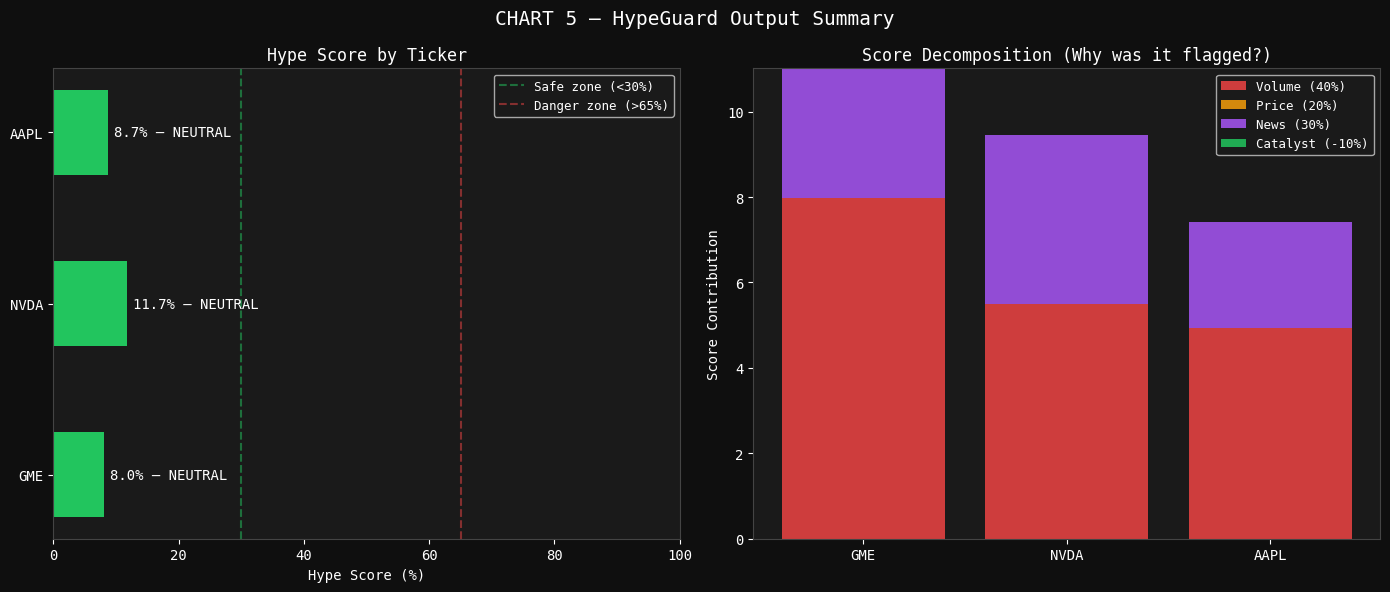


  HYPEGUARD — PHASE 1 COMPLETE SUMMARY

  GME
    Hype Score   : 8.0%
    Label        : NEUTRAL
    RVOL         : 1.00x
    RSI          : 33
    Catalyst     : No

  NVDA
    Hype Score   : 11.7%
    Label        : NEUTRAL
    RVOL         : 0.69x
    RSI          : 43
    Catalyst     : No

  AAPL
    Hype Score   : 8.7%
    Label        : NEUTRAL
    RVOL         : 0.62x
    RSI          : 45
    Catalyst     : No

✓ Saved: chart5_hype_summary.png

Phase 1 (Data Collection + Feature Engineering) — COMPLETE ✓


In [8]:
# ── CHART 5: Hype Score Summary + Investment Advice ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('CHART 5 — HypeGuard Output Summary', color='white', fontsize=14)

# Gauge-style bar chart
ax1 = axes[0]
tickers_list = DEMO_TICKERS
scores = [feature_vectors[t]['cross_features']['hype_score_raw'] * 100 for t in tickers_list]
labels = [feature_vectors[t]['cross_features']['pseudo_label'] for t in tickers_list]
bar_colors = [HYPE_COLOR if s > 60 else ORGANIC_COLOR if s < 30 else ACCENT_COLOR for s in scores]

bars = ax1.barh(tickers_list, scores, color=bar_colors, height=0.5)
ax1.set_xlim(0, 100)
ax1.axvline(30, color=ORGANIC_COLOR, linestyle='--', alpha=0.5, label='Safe zone (<30%)')
ax1.axvline(65, color=HYPE_COLOR, linestyle='--', alpha=0.5, label='Danger zone (>65%)')

for bar, score, label in zip(bars, scores, labels):
    ax1.text(score + 1, bar.get_y() + bar.get_height()/2,
             f'{score:.1f}% — {label}', va='center', color='white', fontsize=10)

ax1.set_xlabel('Hype Score (%)')
ax1.set_title('Hype Score by Ticker', color='white')
ax1.legend(fontsize=9)

# Feature importance breakdown (stacked bar)
ax2 = axes[1]
components = {
    'Volume (40%)':   [min(feature_vectors[t]['flat_features']['rvol']/5, 1)*40 for t in tickers_list],
    'Price (20%)':    [max((feature_vectors[t]['flat_features']['rsi_14']-50)/50,0)*20 for t in tickers_list],
    'News (30%)':     [(feature_vectors[t]['flat_features']['extreme_language_ratio']*15 +
                        feature_vectors[t]['flat_features']['headline_similarity']*10 +
                        (1-feature_vectors[t]['flat_features']['source_diversity'])*5)
                       for t in tickers_list],
    'Catalyst (-10%)':[-feature_vectors[t]['cross_features']['catalyst_flag']*10 for t in tickers_list],
}

comp_colors = [HYPE_COLOR, ACCENT_COLOR, '#a855f7', ORGANIC_COLOR]
bottoms = np.zeros(len(tickers_list))
for (label, vals), color in zip(components.items(), comp_colors):
    vals_arr = np.array(vals)
    ax2.bar(tickers_list, vals_arr, bottom=np.maximum(bottoms, 0),
            label=label, color=color, alpha=0.85)
    bottoms += vals_arr

ax2.set_ylabel('Score Contribution')
ax2.set_title('Score Decomposition (Why was it flagged?)', color='white')
ax2.legend(fontsize=9)
ax2.axhline(0, color='white', linewidth=0.5)

plt.tight_layout()
plt.savefig('../data/chart5_hype_summary.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Final summary table
print('\n' + '='*65)
print('  HYPEGUARD — PHASE 1 COMPLETE SUMMARY')
print('='*65)
for ticker in DEMO_TICKERS:
    vf = feature_vectors[ticker]
    cf = vf['cross_features']
    pf = vf['price_features']
    volf = vf['volume_features']
    print(f"\n  {ticker}")
    print(f"    Hype Score   : {cf['hype_score_raw']*100:.1f}%")
    print(f"    Label        : {cf['pseudo_label']}")
    print(f"    RVOL         : {volf['rvol']:.2f}x")
    print(f"    RSI          : {pf['rsi_14']:.0f}")
    print(f"    Catalyst     : {'Yes' if cf['catalyst_flag'] else 'No'}")
print('\n✓ Saved: chart5_hype_summary.png')
print('\nPhase 1 (Data Collection + Feature Engineering) — COMPLETE ✓')